# VM Allocation Optimization Benckmark

In [ ]:
import random
from vm_allocation.models import Server, VM, Context, Solver
from vm_allocation.datasets.generate_dataset import generate_vms, generate_servers
from vm_allocation.solvers import FFDSolver, PLNESolver, CPSATSolver


## Servers creation

In [185]:
server1, server2, server3 = generate_servers(3)
vms: list[VM] = generate_vms(7)
for vm in vms[:3]:
    server1.add_vm(vm)
for vm in vms[3:]:
    server2.add_vm(vm)
context = Context([server1, server2, server3])

# VISUAL

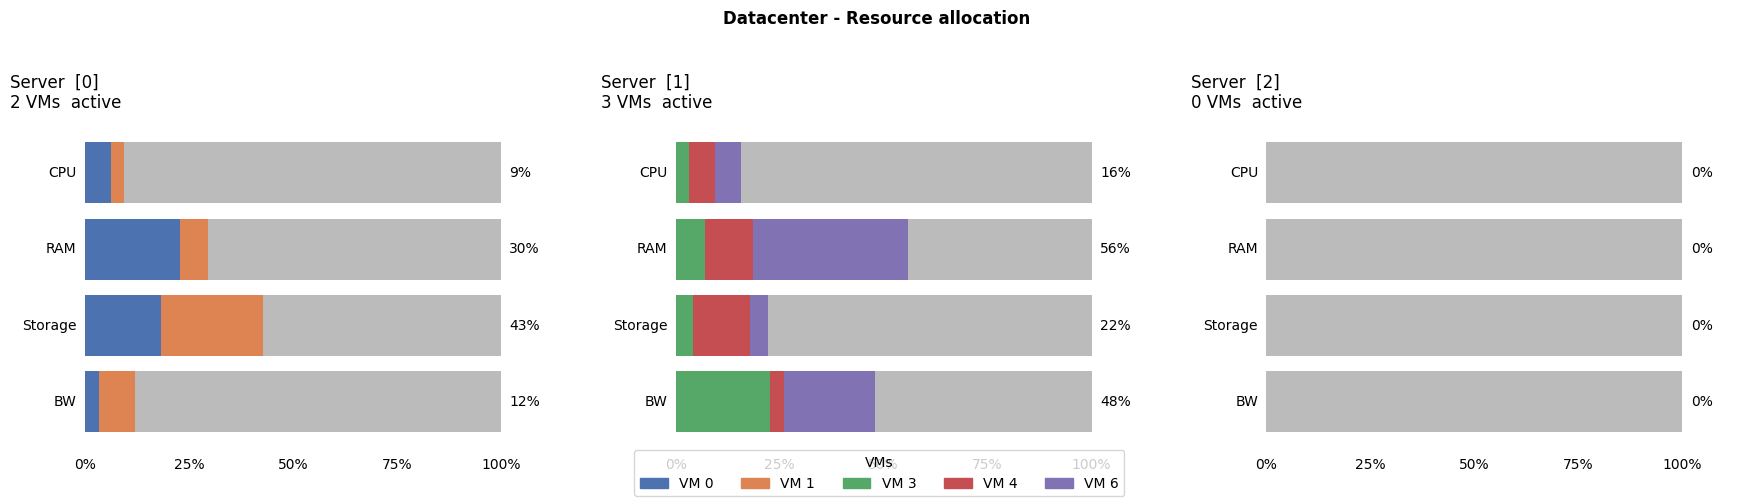

In [186]:
fig = context.plot()

# Virtual Machine Creation

In [194]:
def adjuste_vm_id(context: Context, vms :list[VM]):
    max_id = 0

    for server in context.get_servers():
        for vm in server.get_vms():
            if vm.id > max_id:
                max_id = vm.id

    for vm in vms:
        vm.id = vm.id + max_id

newvms: list[VM] = generate_vms(3)

print(newvms)

adjuste_vm_id(context, newvms)


[<vm_allocation.models.vm.VM object at 0x0000015CA4D71CD0>, <vm_allocation.models.vm.VM object at 0x0000015CA529EDD0>, <vm_allocation.models.vm.VM object at 0x0000015CA529E550>]


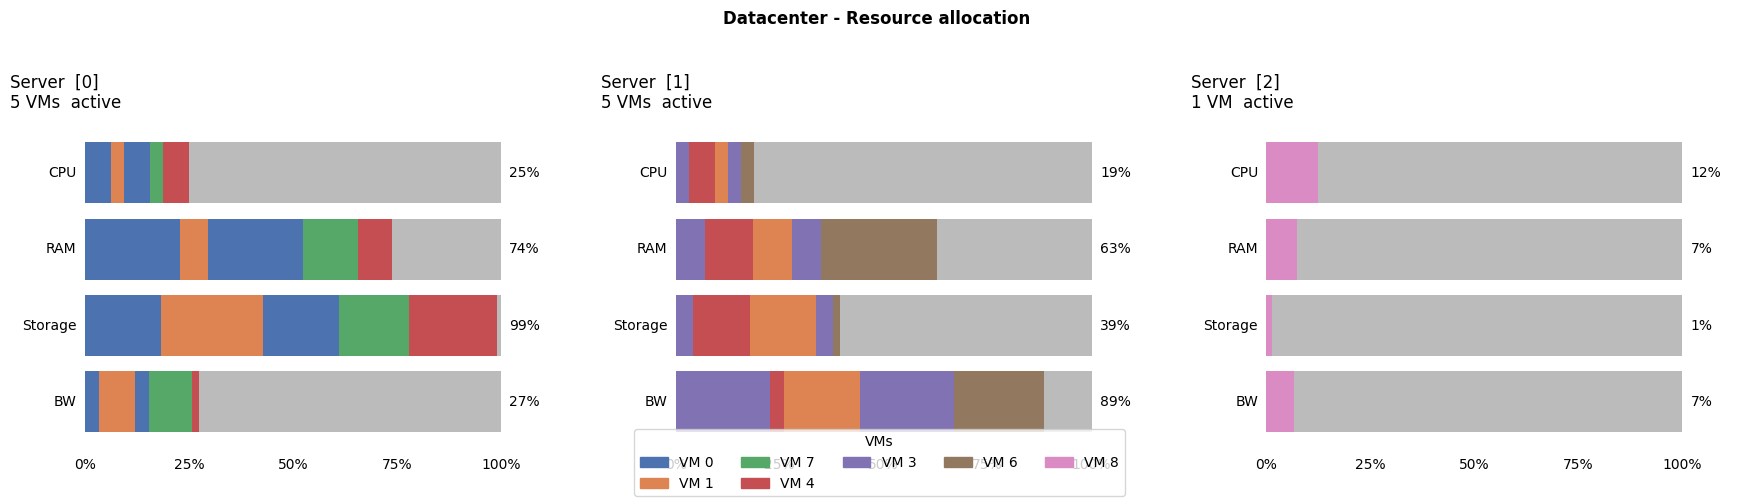

In [ ]:
fdd = FFDSolver()
new_context = fdd.solve(newvms, context)

fig = new_context.plot()
